# State Identification via Federal Funds Rate

## Objective
Identify **economic policy regimes** directly from the Federal Funds Rate series using a
Dirichlet-Multinomial drift-score model. Each calendar day is classified into one of three states:

| State | Meaning |
|---|---|
| **Tightening** | Net upward drift in recent FOMC decisions (D_t ≥ θ) |
| **Easing** | Net downward drift (D_t ≤ −θ) |
| **Plateau** | Rate flat or mixed — hold-high, hold-low, or neutral |

Each row also carries a **soft probability distribution** (p_tightening, p_easing, p_plateau)
via Bayesian Dirichlet-Multinomial smoothing, capturing uncertainty in borderline periods.

### Steps
1. **Load & stitch** the Federal Funds Rate series into a single continuous daily series
2. **Label regimes** — define and validate the `label_policy_regime()` function
3. **Apply to real data** — run the labeler on `fedrate_all.csv` and visualize results
4. **Regime probability distribution** — stacked area chart of soft state probabilities


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── GitHub raw data URLs ───────────────────────────────────────────────────
_BASE        = "https://raw.githubusercontent.com/echochoho1010/forecasting_fed_rate/master/data"
URL_DFEDTAR  = f"{_BASE}/Federal%20Funds%20Target%20Rate.csv"
URL_DFEDTARU = f"{_BASE}/Federal%20Funds%20Target%20Range%20Upper%20Limit.csv"
URL_FEDRATE  = f"{_BASE}/fedrate_all.csv"

print("Imports ready.")
print(f"  Base URL : {_BASE}")


---
## Step 1 — Load Federal Funds Rate

Stitch the single-target era (`DFEDTAR`, 1986–2008) and target-range era (`DFEDTARU`, 2008–present)
into one continuous daily `fed_rate` series. This is the sole input to the regime labeler.


In [ ]:
# ── Load raw series ───────────────────────────────────────────────────────
df_tar = pd.read_csv(URL_DFEDTAR)
df_tar['observation_date'] = pd.to_datetime(df_tar['observation_date'])
df_tar['DFEDTAR'] = pd.to_numeric(df_tar['DFEDTAR'], errors='coerce')
df_tar = df_tar.dropna().sort_values('observation_date').reset_index(drop=True)

df_rng = pd.read_csv(URL_DFEDTARU)
df_rng['observation_date'] = pd.to_datetime(df_rng['observation_date'])
df_rng['DFEDTARU'] = pd.to_numeric(df_rng['DFEDTARU'], errors='coerce')
df_rng = df_rng.dropna().sort_values('observation_date').reset_index(drop=True)

# ── Stitch at 2008-12-16 (FOMC switch to target range) ────────────────────
SWITCH_DATE = pd.Timestamp('2008-12-16')
pre  = df_tar[df_tar['observation_date'] < SWITCH_DATE][['observation_date', 'DFEDTAR']].rename(columns={'DFEDTAR': 'fed_rate'})
post = df_rng[['observation_date', 'DFEDTARU']].rename(columns={'DFEDTARU': 'fed_rate'})

df_fedrate = (
    pd.concat([pre, post], ignore_index=True)
    .sort_values('observation_date')
    .drop_duplicates('observation_date')
    .reset_index(drop=True)
)

print(f'Fed rate series: {df_fedrate["observation_date"].min().date()} → {df_fedrate["observation_date"].max().date()}  ({len(df_fedrate):,} rows)')
print(f'Value range    : {df_fedrate["fed_rate"].min():.2f}% – {df_fedrate["fed_rate"].max():.2f}%')
df_fedrate.head(3)


---
## Step 2 — Policy Regime Labeling

Classify each time point into one of three regimes and output a **soft probability
distribution** over those three states using a Dirichlet-Multinomial model.

### 2.0 Output: Hard Label + Probability Distribution

Each row carries both a **hard label** (`regime_simple`) and a full **probability vector**:

| Column | Type | Meaning |
|---|---|---|
| `regime` | string | Filtered hard label (5 states) after persistence check |
| `regime_simple` | string | Collapsed hard label: **Tightening / Easing / Plateau** |
| `p_tightening` | float ∈ [0,1] | P(Tightening) — Dirichlet-Multinomial model |
| `p_easing` | float ∈ [0,1] | P(Easing) |
| `p_plateau` | float ∈ [0,1] | P(Plateau) — always: p_tight + p_ease + p_plat = 1 |

The three always sum to 1.0 at every row, making them a valid probability distribution.

### 2.1 How the Hard Label Works

The five internal states are collapsed into three via the `regime_simple` column:

| `regime_simple` | Internal states | Meaning |
|---|---|---|
| **Tightening** | Tightening | D_t ≥ θ — net upward drift in recent decisions |
| **Easing** | Easing | D_t ≤ −θ — net downward drift in recent decisions |
| **Plateau** | Hold-High, Hold-Low, Neutral Hold / Transition | \|D_t\| < θ — rate flat or mixed |

**Drift score D_t** — for each FOMC-frequency event (rate-change days + synthetic holds):

$$D_t = \frac{H_t - C_t}{W} \in [-1,\ 1]$$

where $H_t$ = hike count and $C_t$ = cut count over the last $W$ events.

### 2.2 How the Probability Distribution Works

Rather than a single confidence scalar, the model outputs a full probability vector
using a **Dirichlet-Multinomial** (Bayesian count) approach:

$$P(\text{state}) = \frac{\text{count}_{\text{state}} + \alpha}{n_{\text{events in window}} + 3\alpha}$$

where $N_t = n_{\text{events}} - H_t - C_t$ is the hold count, and $\alpha$ is the Laplace
smoothing concentration (default 1.0).

**Key property** — the probability distribution captures *uncertainty* that the hard label hides:
- When D_t = 0.17 (barely above θ=0.15), hard label = **Tightening**,
  but with H=1, C=0, N=5 in a W=6 window → **P(Plateau)=0.67**, P(Tight)=0.22.
  The distribution honestly reflects that most recent decisions were holds.
- When D_t = 0.83 (clearly Tightening, H=5 hikes), → **P(Tight)=0.78**, near-certain.

This matters for downstream forecasting: the model can use the soft probabilities
as features rather than one-hot hard labels, preserving information about borderline periods.

### 2.3 Key Parameters

| Symbol | Arg | Current value | Meaning |
|---|---|---|---|
| W | `W` | **6** | Rolling window length in FOMC decisions |
| θ | `theta` | **0.15** | Drift threshold for hard label |
| k | `k` | **1** | ±decisions for local max/min (analysis mode only) |
| ε | `epsilon_bps` | 0.25 | "Near max/min" tolerance (analysis mode only) |
| m | `m` | **1** | Persistence: consecutive events to confirm a regime change |
| α | `alpha` | **1.0** | Dirichlet smoothing: ↓ → sharper distribution; ↑ → softer |

**Sensitivity trade-offs:**

| Want… | Change |
|---|---|
| Plateau detected sooner / more small plateaus | ↑ `theta` or ↓ `W` or ↓ `m` |
| Brief pauses ignored (stay Tightening/Easing) | ↓ `theta` or ↑ `W` or ↑ `m` |
| Faster state-change detection | ↓ `m` |
| Sharper probability distribution | ↓ `alpha` |
| Softer probability distribution | ↑ `alpha` |

> **Daily data note:** Raw daily data has no explicit Hold-meeting rows. The wrapper
> `label_policy_regime_daily()` inserts synthetic Hold events every `fomc_cycle_days` days
> (default 42 ≈ FOMC cadence) so the rolling window is properly diluted during flat-rate periods.
> Plateau detection lag ≈ (W + m) × fomc_cycle_days ≈ (6 + 1) × 42 = **294 days ≈ 10 months**.

In [121]:
def label_policy_regime(
    df,
    rate_col="fed_rate",
    date_col="observation_date",
    W=6,
    theta=0.15,
    k=1,
    epsilon_bps=0.25,
    m=1,
    tol=1e-9,
    mode="realtime",
    alpha=1.0,
):
    """
    Label each row with a policy regime and output a soft probability
    distribution over three states: Tightening, Easing, Plateau.

    Parameters
    ----------
    df           : DataFrame with at least date_col and rate_col columns.
    rate_col     : Column name for the policy rate.
    date_col     : Column name for dates.
    W            : Rolling window length (in events) for computing H_t, C_t, D_t.
                   Default 6 (≈ 6 FOMC meetings).
    theta        : Drift threshold for Tightening / Easing.
                   Default 0.15 — a single hike in W=6 gives D_t=1/6≈0.17 > θ,
                   so the regime stays directional unless ALL recent events are holds.
    k            : Half-window for local max/min detection (analysis mode only).
                   Default 1 (uses ±1 event around each point).
    epsilon_bps  : Tolerance (in rate units) for "near" local max/min. Default 0.25.
    m            : Persistence filter — consecutive events required to confirm a
                   regime change. Default 1 (immediate confirmation; increase to
                   suppress tiny spurious states at the cost of detection lag).
    tol          : |Δr| < tol  ⟹  Hold (float equality guard). Default 1e-9.
    mode         : 'realtime' (no leakage, causal) or 'analysis' (uses ±k future
                   events for local max/min). Default 'realtime'.
    alpha        : Laplace (Dirichlet) smoothing concentration for the probability
                   output. Default 1.0 (add-one smoothing).
                   ↓ alpha → sharper / more peaked distribution
                   ↑ alpha → softer / more uniform distribution

    Probability Model
    -----------------
    Treats the last W decisions as Multinomial draws from (Hike, Cut, Hold)
    and applies Dirichlet-Multinomial smoothing with concentration alpha:

        P(state) = (count_state + α) / (n_events_in_window + 3·α)

    Examples with W=6, α=1:
      · Pure Tightening (H=6, C=0, N=0) → P(Tight)=7/9≈0.78, P(Ease)=P(Plat)=1/9≈0.11
      · Pure Easing     (H=0, C=6, N=0) → P(Ease) =7/9≈0.78
      · Pure Plateau    (H=0, C=0, N=6) → P(Plat) =7/9≈0.78
      · Borderline      (H=1, C=0, N=5) → P(Tight)=2/9≈0.22, P(Plat)=6/9≈0.67
        (hard label = Tightening since D_t=1/6>θ, but distribution shows high plateau weight)

    Sensitivity quick reference
    ---------------------------
    Fewer tiny blips / less fragmentation  →  ↑ m  or  ↑ W  or  ↓ theta
    Plateau detected faster                →  ↑ theta  or  ↓ W  or  ↓ m
    Faster directional detection           →  ↓ m
    Sharper probability distribution       →  ↓ alpha
    Softer probability distribution        →  ↑ alpha

    Returns
    -------
    DataFrame copy with added columns:
        delta_r      — Δr_t = rate_t - rate_{t-1}  (NaN at t=0)
        decision     — 'Hike', 'Cut', or 'Hold'     (NaN at t=0)
        H_t          — hike count in last W events (rolling, min_periods=1)
        C_t          — cut count  in last W events
        N_t          — hold count in last W events  (= n_events_in_window − H_t − C_t)
        D_t          — (H_t - C_t) / W  ∈ [-1, 1], the drift score
        raw_regime   — regime before persistence filter
        regime       — regime after persistence filter (final hard label)
        regime_change— True where regime switched from the previous row
        p_tightening — P(Tightening) ∈ [0, 1]  from Dirichlet-Multinomial model
        p_easing     — P(Easing)     ∈ [0, 1]
        p_plateau    — P(Plateau)    ∈ [0, 1]   (three always sum to 1.0)
    """
    assert mode in ("realtime", "analysis"), "mode must be 'realtime' or 'analysis'"

    # ── 0. Copy, sort, forward-fill missing values ────────────────────────────
    df_out = df.copy()
    if date_col in df_out.columns:
        df_out = df_out.sort_values(date_col).reset_index(drop=True)

    rate = df_out[rate_col].copy()
    n_missing = rate.isna().sum()
    if n_missing > 0:
        print(f"[label_policy_regime] Forward-filling {n_missing} missing rate value(s).")
        rate = rate.ffill()

    n = len(rate)

    # ── 1. Δr_t and per-row decision ─────────────────────────────────────────
    delta_r  = rate.diff()                          # NaN at t=0
    decision = pd.Series("Hold", index=rate.index, dtype=object)
    decision[delta_r >  tol] = "Hike"
    decision[delta_r < -tol] = "Cut"
    decision[delta_r.isna()] = None                 # t=0 has no predecessor

    # ── 2. Rolling counts H_t, C_t  →  drift score D_t ───────────────────────
    # fillna(False) so the NaN at t=0 contributes 0 to rolling counts.
    is_hike = (decision == "Hike").fillna(False).astype(float)
    is_cut  = (decision == "Cut" ).fillna(False).astype(float)

    H_t = is_hike.rolling(W, min_periods=1).sum()
    C_t = is_cut .rolling(W, min_periods=1).sum()
    D_t = (H_t - C_t) / W                          # ∈ [-1, 1]

    # ── 2b. Hold count N_t  →  Dirichlet probability distribution ────────────
    # n_events: number of decisions inside the rolling window at each row.
    # With min_periods=1 rolling, this grows from 1 up to W then stays at W.
    n_events = (pd.Series(range(1, n + 1), index=rate.index, dtype=float)
                  .clip(upper=W))
    N_t = (n_events - H_t - C_t).clip(lower=0)     # hold count in window

    # Bayesian Dirichlet-Multinomial with Laplace smoothing (alpha):
    #   P(state) = (count_state + alpha) / (n_events + 3·alpha)
    # Guarantees p_tight + p_ease + p_plateau = 1 at every row.
    denom        = n_events + 3.0 * alpha
    p_tightening = (H_t + alpha) / denom
    p_easing     = (C_t + alpha) / denom
    p_plateau    = (N_t + alpha) / denom

    # ── 3a. Real-time: track last non-hold direction ──────────────────────────
    last_dir    = [None] * n
    current_dir = None
    for i in range(n):
        d = decision.iloc[i]
        if d == "Hike":
            current_dir = "Hike"
        elif d == "Cut":
            current_dir = "Cut"
        # d == "Hold" or None: current_dir unchanged
        last_dir[i] = current_dir

    # ── 3b. Analysis: local max / min using symmetric window [t-k, t+k] ───────
    if mode == "analysis":
        rate_vals    = rate.values.astype(float)
        is_local_max = np.zeros(n, dtype=bool)
        is_local_min = np.zeros(n, dtype=bool)

        for i in range(n):
            lo, hi = max(0, i - k), min(n - 1, i + k)
            window = rate_vals[lo : hi + 1]
            if rate_vals[i] == window.max():
                is_local_max[i] = True
            if rate_vals[i] == window.min():
                is_local_min[i] = True

        # Running most-recent local max/min value (causal scan left-to-right)
        most_recent_lmax = np.full(n, np.nan)
        most_recent_lmin = np.full(n, np.nan)
        last_lmax_val = np.nan
        last_lmin_val = np.nan
        for i in range(n):
            if is_local_max[i]:
                last_lmax_val = rate_vals[i]
            if is_local_min[i]:
                last_lmin_val = rate_vals[i]
            most_recent_lmax[i] = last_lmax_val
            most_recent_lmin[i] = last_lmin_val

    # ── 3c. Assign raw_regime ─────────────────────────────────────────────────
    raw_regime = []
    for i in range(n):
        dt = D_t.iloc[i]

        if dt >= theta:
            raw_regime.append("Tightening")

        elif dt <= -theta:
            raw_regime.append("Easing")

        else:
            # ---- Hold zone: determine High / Low / Neutral context ----
            if mode == "realtime":
                ld = last_dir[i]
                if   ld == "Hike": raw_regime.append("Hold-High")
                elif ld == "Cut":  raw_regime.append("Hold-Low")
                else:              raw_regime.append("Neutral Hold / Transition")

            else:  # analysis — uses local max/min (future visible)
                rv   = rate_vals[i]
                lmax = most_recent_lmax[i]
                lmin = most_recent_lmin[i]

                near_max = is_local_max[i] or (not np.isnan(lmax) and rv >= lmax - epsilon_bps)
                near_min = is_local_min[i] or (not np.isnan(lmin) and rv <= lmin + epsilon_bps)

                if   near_max and not near_min: raw_regime.append("Hold-High")
                elif near_min and not near_max: raw_regime.append("Hold-Low")
                elif near_max and near_min:
                    ld = last_dir[i]
                    if   ld == "Hike": raw_regime.append("Hold-High")
                    elif ld == "Cut":  raw_regime.append("Hold-Low")
                    else:              raw_regime.append("Neutral Hold / Transition")
                else:
                    raw_regime.append("Neutral Hold / Transition")

    # ── 4. Persistence filter: only switch regime after m consecutive rows ─────
    final_regime   = [None] * n
    current_regime = raw_regime[0]
    candidate      = None
    cand_count     = 0

    for i in range(n):
        r = raw_regime[i]

        if r == current_regime:
            candidate  = None
            cand_count = 0
        else:
            if r == candidate:
                cand_count += 1
            else:
                candidate  = r
                cand_count = 1

            if cand_count >= m:
                current_regime = candidate
                candidate      = None
                cand_count     = 0

        final_regime[i] = current_regime

    # ── 5. regime_change flag ─────────────────────────────────────────────────
    final_s       = pd.Series(final_regime, index=rate.index)
    regime_change = final_s != final_s.shift(1)
    regime_change.iloc[0] = False

    # ── 6. Attach columns and return ─────────────────────────────────────────
    df_out["delta_r"]      = delta_r.values
    df_out["decision"]     = decision.values
    df_out["H_t"]          = H_t.values
    df_out["C_t"]          = C_t.values
    df_out["N_t"]          = N_t.values
    df_out["D_t"]          = D_t.values
    df_out["raw_regime"]   = raw_regime
    df_out["regime"]       = final_regime
    df_out["regime_change"]= regime_change.values
    df_out["p_tightening"] = p_tightening.values
    df_out["p_easing"]     = p_easing.values
    df_out["p_plateau"]    = p_plateau.values

    return df_out


print("label_policy_regime() defined — outputs p_tightening, p_easing, p_plateau.")


label_policy_regime() defined — outputs p_tightening, p_easing, p_plateau.


### 2a. Synthetic Demo — edge cases and label verification

In [122]:
# ── Synthetic rate series: Hike cycle → Easing ───────────────────────────────
#
#  Expected behaviour with W=6, theta=0.15, alpha=1.0, m=1 (realtime)
#  ─────────────────────────────────────────────────────────────────────────────
#  Key insight: the hard label (regime) and the probability distribution
#  tell different stories — and that's intentional.
#
#  The hard label uses D_t vs theta (threshold test).
#  The probability uses Dirichlet-Multinomial on raw counts H, C, N.
#
#  This means a "borderline" period shows P(Plateau) high even when the
#  hard label still says Tightening — correctly capturing uncertainty.
#
#  Date     Rate  Dec.   H  C  N  D_t   p_tight  p_ease  p_plat  regime
#  ───────  ────  ─────  ─  ─  ─  ────  ───────  ──────  ──────  ─────────
#  Jan 20   0.25  –      0  0  1  0.00  0.25     0.25    0.50    Neutral Hold
#  Feb 20   0.50  Hike   1  0  1  0.17  0.40     0.20    0.40    Tightening  ← D_t>θ, but prob uncertain (40/20/40)
#  Mar 20   0.75  Hike   2  0  1  0.33  0.50     0.17    0.33    Tightening
#  Apr 20   1.00  Hike   3  0  1  0.50  0.57     0.14    0.29    Tightening
#  May 20   1.25  Hike   4  0  1  0.67  0.63     0.13    0.25    Tightening
#  Jun 20   1.50  Hike   5  0  1  0.83  0.67     0.11    0.22    Tightening
#  Jul 20   1.50  Hold   5  0  1  0.83  0.67     0.11    0.22    Tightening
#  Aug 20   1.50  Hold   4  0  2  0.67  0.56     0.11    0.33    Tightening
#  Sep 20   1.50  Hold   3  0  3  0.50  0.44     0.11    0.44    Tightening  ← P(Plat) rising!
#  Oct 20   1.25  Cut    2  1  3  0.17  0.33     0.22    0.44    Tightening  ← D_t=0.17>θ → still hard Tightening
#                                                                             but P(Plat)=0.44 highest!
#  Nov 20   1.00  Cut    1  2  3 -0.17  0.22     0.33    0.44    Easing      ← D_t<-θ → hard flip to Easing
#  Dec 20   0.75  Cut    0  3  3 -0.50  0.11     0.44    0.44    Easing
#  Jan 21   0.50  Cut    0  4  2 -0.67  0.11     0.56    0.33    Easing
#  Feb 21   0.25  Cut    0  5  1 -0.83  0.11     0.67    0.22    Easing
#  Mar 21   0.25  Hold   0  5  1 -0.83  0.11     0.67    0.22    Easing      ← 5 cuts still in window
#  Apr 21   0.25  Hold   0  4  2 -0.67  0.11     0.56    0.33    Easing
#
#  Notable: series ends in Easing (never clears to Plateau) because
#  theta=0.15 is low — cuts dominate the window for longer.

syn_rates = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50,
             1.50, 1.50, 1.50,
             1.25, 1.00, 0.75, 0.50, 0.25,
             0.25, 0.25]
syn_dates = pd.date_range("2020-01-01", periods=len(syn_rates), freq="MS")

df_syn = pd.DataFrame({"date": syn_dates, "rate": syn_rates})

# ── Run both modes with current parameters ────────────────────────────────────
df_syn_rt = label_policy_regime(df_syn, rate_col="rate", date_col="date",
                                 W=6, theta=0.15, k=1, m=1, alpha=1.0,
                                 mode="realtime")
df_syn_an = label_policy_regime(df_syn, rate_col="rate", date_col="date",
                                 W=6, theta=0.15, k=1, epsilon_bps=0.25, m=1,
                                 alpha=1.0, mode="analysis")

cols_show = ["date", "rate", "decision", "H_t", "C_t", "N_t", "D_t",
             "regime", "p_tightening", "p_easing", "p_plateau"]
print("=== REALTIME MODE  (W=6, θ=0.15, α=1.0, m=1) ===")
display(df_syn_rt[cols_show].round(3))

print("\n=== ANALYSIS MODE  (W=6, θ=0.15, k=1, α=1.0, m=1) ===")
display(df_syn_an[cols_show].round(3))

# ── Sanity check: probabilities must sum to 1 ─────────────────────────────────
p_sum = df_syn_rt[["p_tightening", "p_easing", "p_plateau"]].sum(axis=1)
print(f"\n✓ Probability sums — all equal 1.0: {np.allclose(p_sum, 1.0)}")
print(f"  Regime changes (realtime) : {df_syn_rt['regime_change'].sum()}")
print(f"  Regime changes (analysis) : {df_syn_an['regime_change'].sum()}")


=== REALTIME MODE  (W=6, θ=0.15, α=1.0, m=1) ===


,date,rate,decision,H_t,C_t,N_t,D_t,regime,p_tightening,p_easing,p_plateau
0,2020-01-01,0.25,None,0.0,0.0,1.0,0.000,Neutral Hold / Transition,0.250,0.250,0.500
1,2020-02-01,0.50,Hike,1.0,0.0,1.0,0.167,Tightening,0.400,0.200,0.400
2,2020-03-01,0.75,Hike,2.0,0.0,1.0,0.333,Tightening,0.500,0.167,0.333
3,2020-04-01,1.00,Hike,3.0,0.0,1.0,0.500,Tightening,0.571,0.143,0.286
4,2020-05-01,1.25,Hike,4.0,0.0,1.0,0.667,Tightening,0.625,0.125,0.250
5,2020-06-01,1.50,Hike,5.0,0.0,1.0,0.833,Tightening,0.667,0.111,0.222
6,2020-07-01,1.50,Hold,5.0,0.0,1.0,0.833,Tightening,0.667,0.111,0.222
7,2020-08-01,1.50,Hold,4.0,0.0,2.0,0.667,Tightening,0.556,0.111,0.333
8,2020-09-01,1.50,Hold,3.0,0.0,3.0,0.500,Tightening,0.444,0.111,0.444
9,2020-10-01,1.25,Cut,2.0,1.0,3.0,0.167,Tightening,0.333,0.222,0.444



=== ANALYSIS MODE  (W=6, θ=0.15, k=1, α=1.0, m=1) ===


,date,rate,decision,H_t,C_t,N_t,D_t,regime,p_tightening,p_easing,p_plateau
0,2020-01-01,0.25,None,0.0,0.0,1.0,0.000,Hold-Low,0.250,0.250,0.500
1,2020-02-01,0.50,Hike,1.0,0.0,1.0,0.167,Tightening,0.400,0.200,0.400
2,2020-03-01,0.75,Hike,2.0,0.0,1.0,0.333,Tightening,0.500,0.167,0.333
3,2020-04-01,1.00,Hike,3.0,0.0,1.0,0.500,Tightening,0.571,0.143,0.286
4,2020-05-01,1.25,Hike,4.0,0.0,1.0,0.667,Tightening,0.625,0.125,0.250
5,2020-06-01,1.50,Hike,5.0,0.0,1.0,0.833,Tightening,0.667,0.111,0.222
6,2020-07-01,1.50,Hold,5.0,0.0,1.0,0.833,Tightening,0.667,0.111,0.222
7,2020-08-01,1.50,Hold,4.0,0.0,2.0,0.667,Tightening,0.556,0.111,0.333
8,2020-09-01,1.50,Hold,3.0,0.0,3.0,0.500,Tightening,0.444,0.111,0.444
9,2020-10-01,1.25,Cut,2.0,1.0,3.0,0.167,Tightening,0.333,0.222,0.444



✓ Probability sums — all equal 1.0: True
  Regime changes (realtime) : 2
  Regime changes (analysis) : 2


### 2b. Apply to `fedrate_all.csv`

Raw daily data only records rate **changes** — Hold decisions (meetings where the Fed did nothing)
leave no footprint in the series.  The wrapper `label_policy_regime_daily()` reconstructs an
approximate meeting-frequency series by inserting one synthetic **Hold** event every
`fomc_cycle_days` days inside each flat-rate segment.

**Current parameters:**

| Parameter | Value | Rationale |
|---|---|---|
| `W` | **6** | Rolling window of 6 FOMC decisions |
| `theta` | **0.15** | 1 lone hike in 6 events → D_t ≈ 0.17 > θ → stays Tightening; exits only when all 6 are holds |
| `k` | **1** | ±1 decision for local max/min in analysis mode |
| `m` | **1** | Immediate confirmation — no detection lag |
| `fomc_cycle_days` | **42** | Standard FOMC cadence ≈ 6 weeks |

**Plateau detection lag** ≈ (W + m) × fomc_cycle_days = **7 × 42 = 294 days ≈ 10 months**
(time from last rate change until Plateau is confirmed, assuming all subsequent events are holds)

In [123]:
def label_policy_regime_daily(
    df,
    rate_col="fed_rate",
    date_col="observation_date",
    W=6, theta=0.15, k=1, epsilon_bps=0.25, m=1, tol=1e-9, mode="realtime",
    fomc_cycle_days=42, alpha=1.0,
):
    """
    Wrapper for DAILY rate data that reconstructs an approximate FOMC
    meeting-frequency event series before calling label_policy_regime().

    WHY THIS IS NEEDED
    ------------------
    Raw daily rate data only records rate *changes* (hike/cut days).
    Hold decisions — meetings where the Fed kept rates unchanged — leave no
    trace.  Without them, the rolling window of W events is never diluted by
    consecutive holds, so D_t stays ≥ θ indefinitely after a hiking cycle
    and Plateau is never detected.

    THE FIX
    -------
    For each constant-rate segment (between two rate changes), insert one
    synthetic "Hold" event every `fomc_cycle_days` days.  This approximates
    the real FOMC cadence (~8 meetings/year ≈ every 42 days) without needing
    the exact meeting calendar.

    PLATEAU DETECTION LAG
    ---------------------
    With theta=0.15 and W=6: the regime exits Tightening only when ALL W=6
    recent events are holds (D_t = 0 < 0.15).  That requires W full hold
    events, then m more to confirm:

        lag ≈ (W + m) × fomc_cycle_days
            = (6 + 1) × 42 = 294 days ≈ 10 months   (current settings)

    Parameters
    ----------
    W               : Rolling window in FOMC decisions. Default 6.
    theta           : Drift threshold. Default 0.15.
    k               : ±decisions for local max/min (analysis mode). Default 1.
    epsilon_bps     : Near-peak/trough tolerance in rate units. Default 0.25.
    m               : Consecutive events to confirm a regime change. Default 1.
    fomc_cycle_days : Days between synthetic Hold insertions. Default 42 ≈ 6 wks.
                      ↓ smaller → more holds inserted → Plateau detected sooner.
    alpha           : Laplace smoothing for probability output. Default 1.0.
                      ↓ alpha → sharper probabilities; ↑ alpha → softer.
    """
    df = df.copy().sort_values(date_col).reset_index(drop=True)
    rate        = df[rate_col].ffill()
    delta_r_abs = rate.diff().abs()

    # ── Step 1: Build approximate meeting-frequency event series ─────────────
    # Every rate-change day is a definite FOMC event.
    # During each flat-rate segment, insert one synthetic "Hold" every
    # fomc_cycle_days days to approximate the meetings where the Fed held.
    seg_starts = [0] + list(df.index[delta_r_abs > tol].tolist())

    event_idx_set = set()
    for pos, seg_start in enumerate(seg_starts):
        event_idx_set.add(seg_start)
        seg_end        = seg_starts[pos + 1] if (pos + 1 < len(seg_starts)) else len(df)
        seg_start_date = df[date_col].iloc[seg_start]
        seg_len_days   = int((df[date_col].iloc[seg_end - 1] - seg_start_date).days)

        for day_off in range(fomc_cycle_days, seg_len_days, fomc_cycle_days):
            target_date = seg_start_date + pd.Timedelta(days=day_off)
            seg_slice   = df.iloc[seg_start : seg_end]
            nearest_idx = (seg_slice[date_col] - target_date).abs().idxmin()
            event_idx_set.add(nearest_idx)

    event_idx_sorted = sorted(event_idx_set)
    df_events = df.iloc[event_idx_sorted].copy().reset_index(drop=True)

    print(f"  Daily rows   : {len(df):,}")
    print(f"  Event rows   : {len(df_events):,}  "
          f"(rate-change events + synthetic holds every {fomc_cycle_days}d)")

    # ── Step 2: Run meeting-frequency labeling on event rows ──────────────────
    df_ev_lab = label_policy_regime(
        df_events,
        rate_col=rate_col, date_col=date_col,
        W=W, theta=theta, k=k, epsilon_bps=epsilon_bps,
        m=m, tol=tol, mode=mode, alpha=alpha,
    )

    # ── Step 3: Merge event labels back; forward-fill to all calendar days ─────
    label_cols = ["delta_r", "decision", "H_t", "C_t", "N_t", "D_t",
                  "raw_regime", "regime",
                  "p_tightening", "p_easing", "p_plateau"]

    df_daily = df.merge(
        df_ev_lab[[date_col] + label_cols],
        on=date_col, how="left",
    )
    for col in label_cols:
        df_daily[col] = df_daily[col].ffill()

    regime_s = df_daily["regime"].fillna("Neutral Hold / Transition")
    df_daily["regime_change"] = regime_s != regime_s.shift(1)
    df_daily.loc[0, "regime_change"] = False

    # Collapse the five internal states into three for plotting
    PLATEAU_STATES = {"Hold-High", "Hold-Low", "Neutral Hold / Transition"}
    df_daily["regime_simple"] = df_daily["regime"].apply(
        lambda r: "Plateau" if r in PLATEAU_STATES else r
    )

    return df_daily


# ── Load fedrate_all.csv from GitHub (no local file needed) ──────────────────
df_fed = pd.read_csv(URL_FEDRATE, parse_dates=['observation_date'])
df_fed = df_fed.sort_values('observation_date').reset_index(drop=True)

print(f"Loaded fedrate_all: {len(df_fed):,} rows  "
      f"({df_fed['observation_date'].min().date()} → "
      f"{df_fed['observation_date'].max().date()})\n")

# ── Parameters ────────────────────────────────────────────────────────────────
#
#  Sensitivity tuning reference
#  ─────────────────────────────────────────────────────────────────────────────
#  Goal                                  │ Change
#  ──────────────────────────────────────┼────────────────────────────────────
#  Ignore brief pauses (stay directional)│ ↓ theta  OR  ↑ W  OR  ↑ m
#  Detect plateau sooner / more of them  │ ↑ theta  OR  ↓ W  OR  ↓ m
#  Reduce detection lag                  │ ↓ m
#  Suppress tiny spurious states         │ ↑ m
#  Sharper probability distribution      │ ↓ alpha
#  Softer probability distribution       │ ↑ alpha
#  ─────────────────────────────────────────────────────────────────────────────
#
#  Plateau lag ≈ (W + m) × fomc_cycle_days
#
#  Example presets:
#  ─────────────────────────────────────────────────────────────────────────────
#  Label     │  W   theta   m   fomc_days │  Approx lag
#  ──────────┼──────────────────────────────┼───────────────────────────────
#  Sensitive │  4   0.25    1      42      │  ~210 days  ≈   7 months
#  Current   │  6   0.15    1      42      │  ~294 days  ≈  10 months  ← active
#  Stable    │  6   0.15    3      42      │  ~378 days  ≈  12 months

W_MEET     = 6     # rolling window = 6 FOMC decisions; need ALL 6 holds to exit directional
THETA      = 0.15  # D_t threshold: 1 hike in W=6 → D_t=0.17>θ → stays Tightening/Easing
K          = 1     # ±1 decision for local max/min detection (analysis mode only)
EPS        = 0.25  # 25-bps tolerance for "near" local max/min (analysis mode only)
M          = 1     # immediate confirmation: any new regime flips on the first event
FOMC_DAYS  = 42    # synthetic hold cadence ≈ standard FOMC 6-week cycle
ALPHA      = 1.0   # Dirichlet smoothing: 1.0 = add-one, higher = softer distribution

print("── Realtime mode ──")
df_rt = label_policy_regime_daily(
    df_fed, rate_col="fed_rate", date_col="observation_date",
    W=W_MEET, theta=THETA, k=K, epsilon_bps=EPS,
    m=M, mode="realtime", fomc_cycle_days=FOMC_DAYS, alpha=ALPHA,
)

print("\n── Analysis mode ──")
df_an = label_policy_regime_daily(
    df_fed, rate_col="fed_rate", date_col="observation_date",
    W=W_MEET, theta=THETA, k=K, epsilon_bps=EPS,
    m=M, mode="analysis", fomc_cycle_days=FOMC_DAYS, alpha=ALPHA,
)

print("\n── Realtime regime_simple distribution ──")
print(df_rt["regime_simple"].value_counts().to_string())
print("\n── Analysis regime_simple distribution ──")
print(df_an["regime_simple"].value_counts().to_string())

# Verify probabilities always sum to 1.0
prob_sum_rt = (df_rt["p_tightening"] + df_rt["p_easing"] + df_rt["p_plateau"])
prob_sum_an = (df_an["p_tightening"] + df_an["p_easing"] + df_an["p_plateau"])
print(f"\n✓ Realtime  prob sum — min: {prob_sum_rt.min():.6f}  max: {prob_sum_rt.max():.6f}")
print(f"✓ Analysis  prob sum — min: {prob_sum_an.min():.6f}  max: {prob_sum_an.max():.6f}")


Loaded fedrate_all: 14,668 rows  (1986-01-01 → 2026-02-27)

── Realtime mode ──
  Daily rows   : 14,668
  Event rows   : 412  (rate-change events + synthetic holds every 42d)

── Analysis mode ──
  Daily rows   : 14,668
  Event rows   : 412  (rate-change events + synthetic holds every 42d)

── Realtime regime_simple distribution ──
regime_simple
Easing        5048
Tightening    5046
Plateau       4574

── Analysis regime_simple distribution ──
regime_simple
Easing        5048
Tightening    5046
Plateau       4574

✓ Realtime  prob sum — min: 1.000000  max: 1.000000
✓ Analysis  prob sum — min: 1.000000  max: 1.000000


### 2c. Fed Rate Plot — Colored by Regime

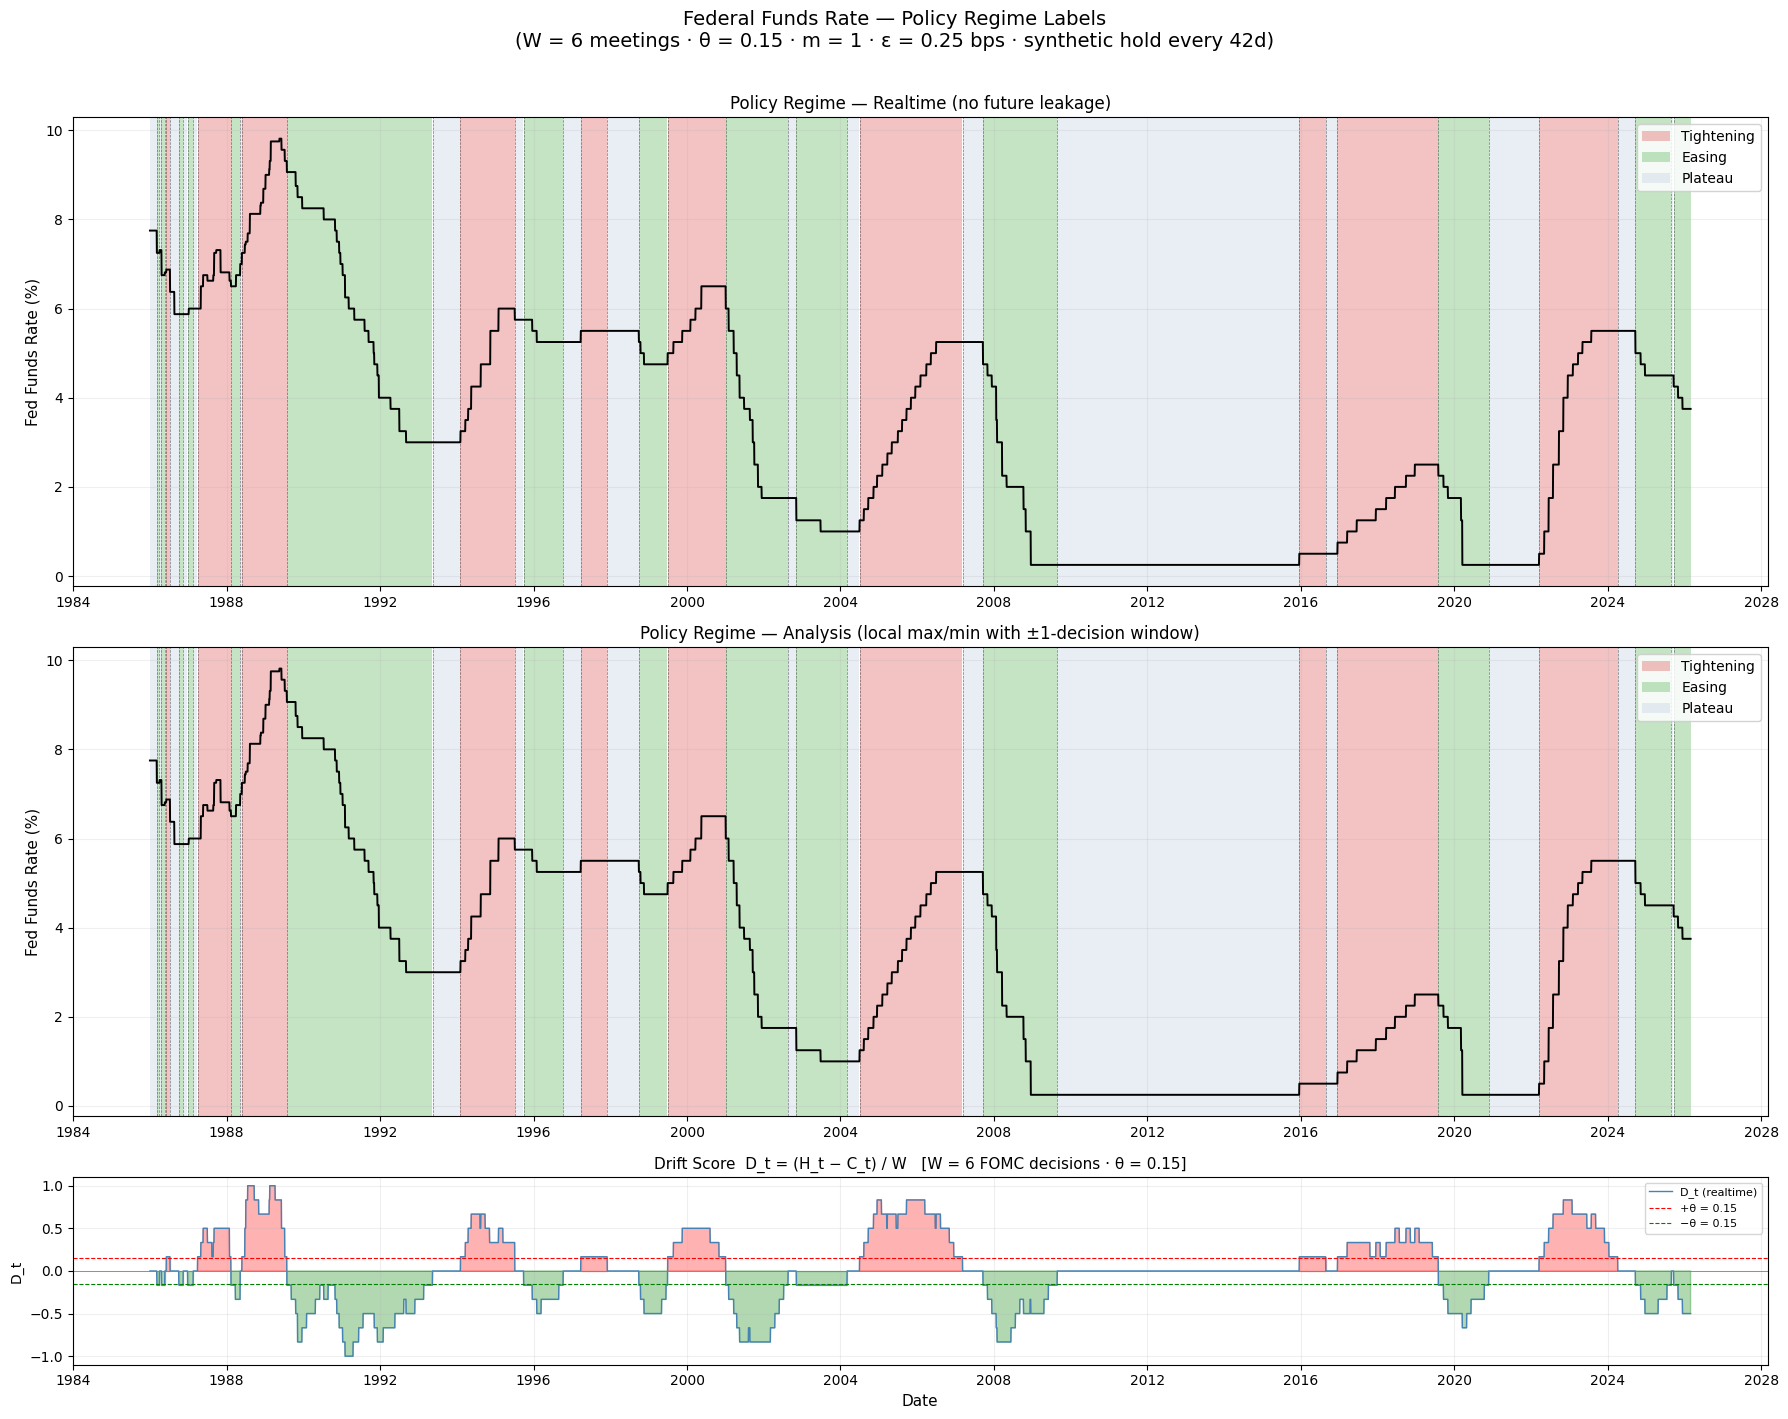

In [124]:
# ── Regime color palette (simplified: 3 states) ───────────────────────────────
REGIME_COLORS_SIMPLE = {
    "Tightening": "#d62728",   # red
    "Easing":     "#2ca02c",   # green
    "Plateau":    "#b0c4de",   # light steel blue
}

def shade_regimes(ax, dates, regimes, colors, alpha=0.28):
    """
    Shade contiguous regime blocks as vertical spans.
    Returns a dict {regime: patch} for building a deduplicated legend.
    """
    dates  = list(dates)
    n      = len(dates)
    legend_handles = {}
    i = 0
    while i < n:
        r = regimes[i]
        j = i
        while j < n and regimes[j] == r:
            j += 1
        color    = colors.get(r, "lightgrey")
        span_end = dates[j - 1] if j < n else dates[-1]
        span     = ax.axvspan(dates[i], span_end, alpha=alpha, color=color, lw=0)
        if r not in legend_handles:
            legend_handles[r] = span
        i = j
    return legend_handles


# ── Main regime plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14),
                          gridspec_kw={"height_ratios": [3, 3, 1.2]})

dates_rt = df_rt["observation_date"].values
dates_an = df_an["observation_date"].values

# ── Panel 1: Realtime regime (regime_simple) ──────────────────────────────────
ax = axes[0]
legend_h = shade_regimes(ax, dates_rt, df_rt["regime_simple"].values, REGIME_COLORS_SIMPLE)
ax.plot(dates_rt, df_rt["fed_rate"], color="black", lw=1.4, zorder=5)

for t in df_rt.index[df_rt["regime_change"]]:
    ax.axvline(dates_rt[t], color="black", lw=0.5, ls="--", alpha=0.5)

ax.set_ylabel("Fed Funds Rate (%)", fontsize=11)
ax.set_title("Policy Regime — Realtime (no future leakage)", fontsize=12)
ordered_labels = [k for k in ["Tightening", "Easing", "Plateau"] if k in legend_h]
ax.legend([legend_h[k] for k in ordered_labels], ordered_labels,
          loc="upper right", fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Panel 2: Analysis regime (regime_simple) ──────────────────────────────────
ax = axes[1]
legend_h2 = shade_regimes(ax, dates_an, df_an["regime_simple"].values, REGIME_COLORS_SIMPLE)
ax.plot(dates_an, df_an["fed_rate"], color="black", lw=1.4, zorder=5)

for t in df_an.index[df_an["regime_change"]]:
    ax.axvline(dates_an[t], color="black", lw=0.5, ls="--", alpha=0.5)

ax.set_ylabel("Fed Funds Rate (%)", fontsize=11)
ax.set_title(f"Policy Regime — Analysis (local max/min with ±{K}-decision window)", fontsize=12)
ordered_labels2 = [k for k in ["Tightening", "Easing", "Plateau"] if k in legend_h2]
ax.legend([legend_h2[k] for k in ordered_labels2], ordered_labels2,
          loc="upper right", fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Panel 3: Drift score D_t ──────────────────────────────────────────────────
ax = axes[2]
ax.plot(dates_rt, df_rt["D_t"], color="steelblue", lw=1.0, label="D_t (realtime)")
ax.axhline( THETA, color="red",   lw=0.8, ls="--", label=f"+θ = {THETA}")
ax.axhline(-THETA, color="green", lw=0.8, ls="--", label=f"−θ = {THETA}")
ax.axhline(0,      color="grey",  lw=0.6)
ax.fill_between(dates_rt, df_rt["D_t"], 0,
                where=df_rt["D_t"] >  THETA, alpha=0.3, color="red",   label="_")
ax.fill_between(dates_rt, df_rt["D_t"], 0,
                where=df_rt["D_t"] < -THETA, alpha=0.3, color="green", label="_")
ax.set_ylabel("D_t", fontsize=10)
ax.set_xlabel("Date", fontsize=11)
ax.set_title(
    f"Drift Score  D_t = (H_t − C_t) / W   "
    f"[W = {W_MEET} FOMC decisions · θ = {THETA}]",
    fontsize=11
)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle(
    "Federal Funds Rate — Policy Regime Labels\n"
    f"(W = {W_MEET} meetings · θ = {THETA} · m = {M} · ε = {EPS} bps"
    f" · synthetic hold every {FOMC_DAYS}d)",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()


### 2d. Regime Probability Distribution

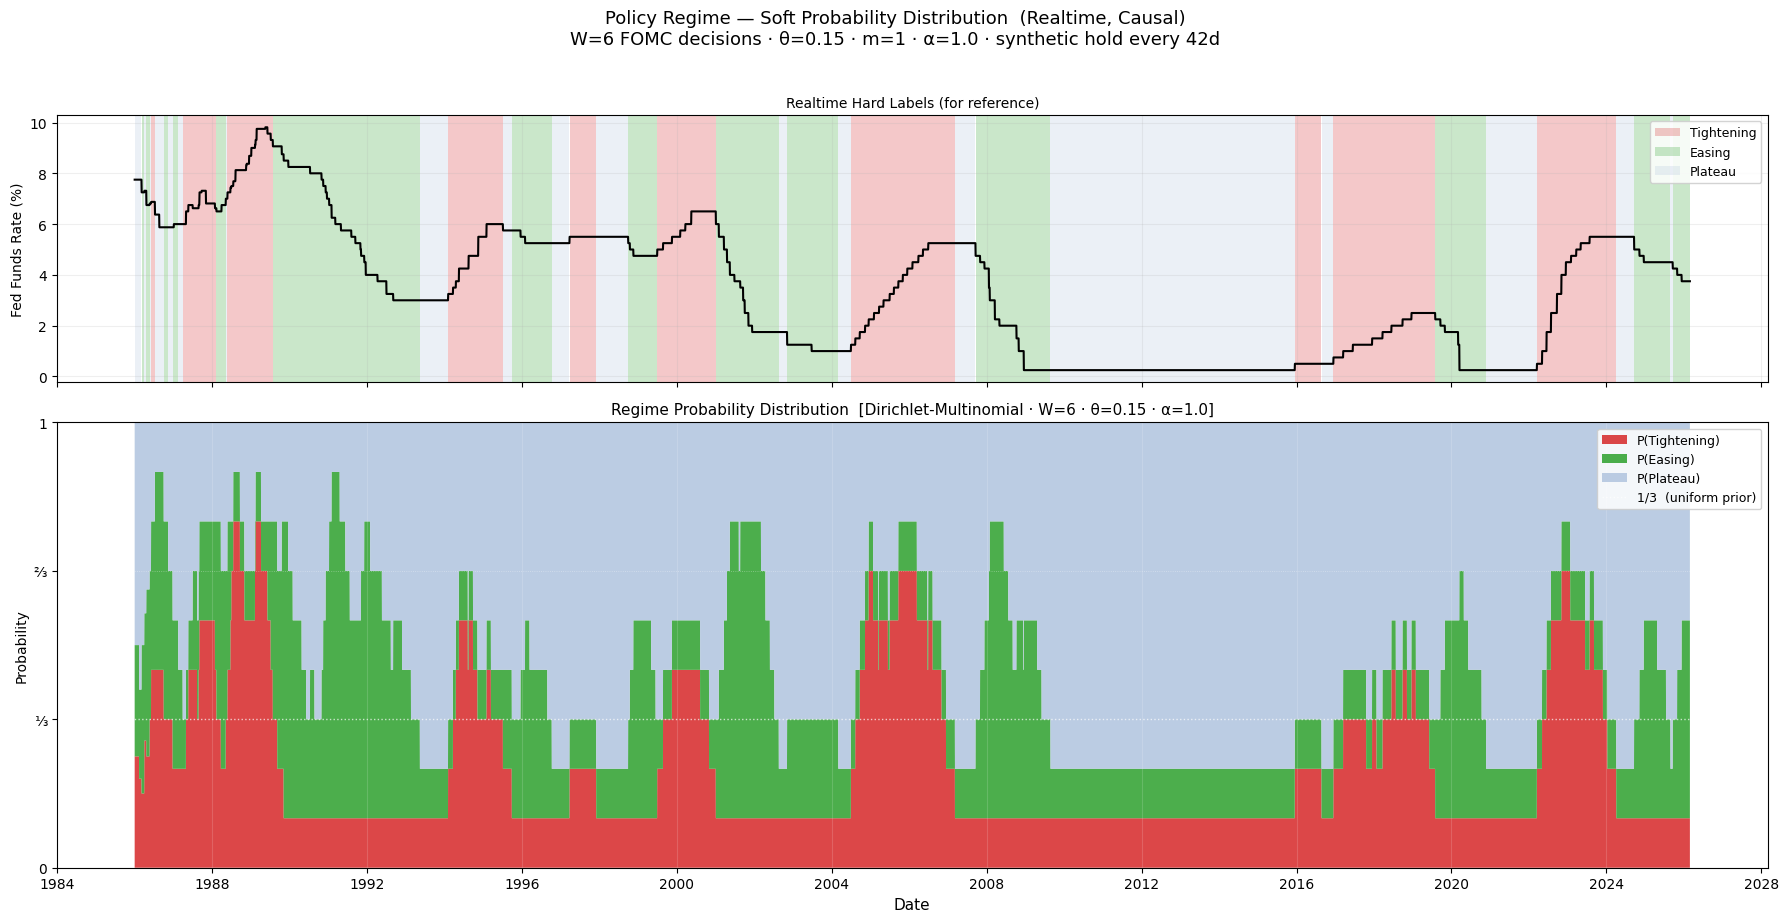


Mean probability vector by hard regime (realtime):
               p_tightening  p_easing  p_plateau
regime_simple                                   
Easing                0.121     0.405      0.473
Plateau               0.126     0.126      0.748
Tightening            0.415     0.121      0.464


In [125]:
# ── 4d. Regime Probability Distribution — Stacked Area Chart ─────────────────
#
# The stacked area chart shows the full soft probability output at every
# calendar day.  Compare with the hard-label shading above to see:
#   · High-confidence periods  → one color dominates (>70%)
#   · Borderline / transitional periods → wide mixed band
#   · The distribution changes smoothly; the hard label "snaps" discretely

fig, (ax_rate, ax_prob) = plt.subplots(
    2, 1, figsize=(18, 9), sharex=True,
    gridspec_kw={"height_ratios": [1.5, 2.5]},
)

dates = df_rt["observation_date"].values

# ── Top panel: Fed rate with realtime regime shading (for reference) ──────────
legend_h = shade_regimes(ax_rate, dates, df_rt["regime_simple"].values,
                          REGIME_COLORS_SIMPLE, alpha=0.25)
ax_rate.plot(dates, df_rt["fed_rate"], color="black", lw=1.5, zorder=5)
ax_rate.set_ylabel("Fed Funds Rate (%)", fontsize=10)
ax_rate.set_title("Realtime Hard Labels (for reference)", fontsize=10)
ax_rate.grid(True, alpha=0.2)
ordered = [k for k in ["Tightening", "Easing", "Plateau"] if k in legend_h]
ax_rate.legend([legend_h[k] for k in ordered], ordered,
               loc="upper right", fontsize=9, framealpha=0.85)
ax_rate.xaxis.set_major_locator(mdates.YearLocator(4))
ax_rate.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Bottom panel: Stacked probability distribution ────────────────────────────
ax_prob.stackplot(
    df_rt["observation_date"],
    df_rt["p_tightening"],
    df_rt["p_easing"],
    df_rt["p_plateau"],
    labels=["P(Tightening)", "P(Easing)", "P(Plateau)"],
    colors=["#d62728", "#2ca02c", "#b0c4de"],
    alpha=0.85,
)

# Reference lines: uniform prior (1/3) and 2/3 majority
ax_prob.axhline(1/3, color="white", lw=1.0, ls=":", alpha=0.7,
                label="1/3  (uniform prior)")
ax_prob.axhline(2/3, color="white", lw=0.6, ls=":", alpha=0.4)
ax_prob.set_ylim(0.0, 1.0)
ax_prob.set_yticks([0, 1/3, 2/3, 1.0])
ax_prob.set_yticklabels(["0", "⅓", "⅔", "1"])
ax_prob.set_ylabel("Probability", fontsize=10)
ax_prob.set_xlabel("Date", fontsize=11)
ax_prob.set_title(
    f"Regime Probability Distribution  "
    f"[Dirichlet-Multinomial · W={W_MEET} · θ={THETA} · α={ALPHA}]",
    fontsize=11,
)
ax_prob.legend(loc="upper right", fontsize=9, framealpha=0.85)
ax_prob.grid(axis="x", alpha=0.15, color="white")
ax_prob.xaxis.set_major_locator(mdates.YearLocator(4))
ax_prob.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle(
    "Policy Regime — Soft Probability Distribution  (Realtime, Causal)\n"
    f"W={W_MEET} FOMC decisions · θ={THETA} · m={M} · α={ALPHA}"
    f" · synthetic hold every {FOMC_DAYS}d",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Spot-check: probability stats per hard regime ─────────────────────────────
print("\nMean probability vector by hard regime (realtime):")
print(df_rt.groupby("regime_simple")[["p_tightening","p_easing","p_plateau"]]
        .mean().round(3).to_string())
